<a href="https://colab.research.google.com/github/KillDare/Analise-EMG/blob/main/An%C3%A1lise_sinal_sEMG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import glob
import re

In [ ]:
fd = 2000; # frequenncia da amostragem em Hz
inicioMoviento = 0; # indica o instante inicio do movimento em segundos
fimMovimento = 6; # indica o tempo final da duração do movimento
localArquivo = '/content/sEMG';
arquivos = glob.glob(os.path.join(localArquivo, '**', '*.csv'), recursive=True) # Busca os arquivos .csv

def extract_number(filename):
    match = re.findall(r'\d+', os.path.basename(filename));
    return int(match[0]) if match else -1  # usa -1 se não encontrar número

arquivos.sort(key=extract_number);

In [ ]:
X = []  # Lista para armazenar os vetores de features
y = []  # Lista para armazenar os rótulos (gestos)

for arquivo in arquivos:
    data = pd.read_csv(arquivo, header=None).values
    for repeticao in range(5):
        repCoef = 4 + 134 * repeticao  # deslocamento temporal da repetição
        for gesto in range(10):  # 10 gestos: 0 a 9
            # Cálculo do início e fim do segmento do gesto
            inicio = int((inicioMoviento + repCoef + gesto * 10) * fd)
            fim = int((fimMovimento + repCoef + gesto * 10) * fd)

            # Segmento multicanal do gesto atual
            dadosMulticanais = data[inicio:fim, :]  # shape: (12000, 4)

            features = []
            for canal in range(dadosMulticanais.shape[1]):
                canal_data = dadosMulticanais[:, canal]

                # Features no domínio do tempo
                features.extend([
                    np.mean(canal_data),
                    np.std(canal_data),
                    np.max(canal_data),
                    np.min(canal_data),
                    np.sqrt(np.mean(canal_data**2)),  # RMS
                    np.median(canal_data),
                ])

                # FFT e features no domínio da frequência
                fft_vals = np.abs(np.fft.rfft(canal_data))
                fft_freqs = np.fft.rfftfreq(len(canal_data), d=1.0/fd)

                # Energia espectral
                spectral_energy = np.sum(fft_vals**2)

                # Frequência média
                mean_freq = np.sum(fft_freqs * fft_vals) / np.sum(fft_vals)

                # Frequência mediana
                cumulative_sum = np.cumsum(fft_vals)
                median_freq = fft_freqs[np.where(cumulative_sum >= cumulative_sum[-1]/2)[0][0]]

                features.extend([
                    spectral_energy,
                    mean_freq,
                    median_freq,
                ])

            # Armazena o vetor de features e o rótulo correspondente
            X.append(features)
            y.append(gesto)

# Conversão final para arrays do numpy
X = np.array(X)
y = np.array(y)


In [ ]:
# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir treino/teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Classificador MLP
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=10000, random_state=42)
mlp.fit(X_train, y_train)

# Avaliação
accuracy = mlp.score(X_test, y_test)
print(f'Acurácia: {accuracy:.2f}')


Acurácia: 0.77


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(mlp, X_scaled, y, cv=kf)
print("Acurácias na validação cruzada:", scores)
print("Média de acurácia:", scores.mean())


Acurácias na validação cruzada: [0.7625 0.755  0.7525 0.7425 0.775 ]
Média de acurácia: 0.7575000000000001


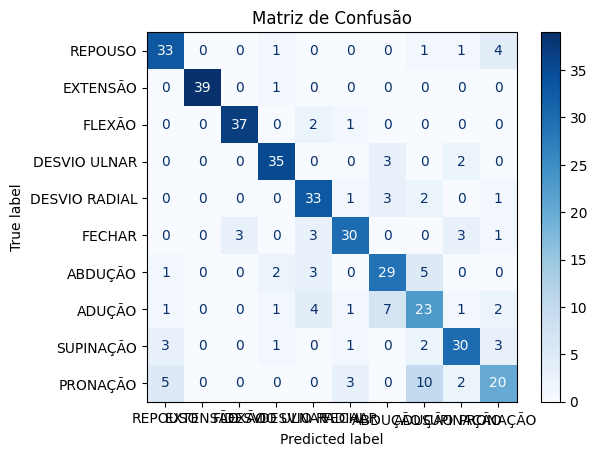

In [ ]:
y_pred = mlp.predict(X_test)  # ou o nome que você usou
cm = confusion_matrix(y_test, y_pred)

# Visualização
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
    "REPOUSO", "EXTENSÃO", "FLEXÃO", "DESVIO ULNAR", "DESVIO RADIAL",
    "FECHAR", "ABDUÇÃO", "ADUÇÃO", "SUPINAÇÃO", "PRONAÇÃO"
])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.show()

In [ ]:
import seaborn as sns

# Precisão por classe = acertos / total de verdadeiros daquela classe
true_positives = np.diag(cm)
total_true = np.sum(cm, axis=1)
precision_per_class = true_positives / total_true

# Nomes dos gestos
labels = [
    "REPOUSO", "EXTENSÃO", "FLEXÃO", "DESVIO ULNAR", "DESVIO RADIAL",
    "FECHAR", "ABDUÇÃO", "ADUÇÃO", "SUPINAÇÃO", "PRONAÇÃO"
]


<ipython-input-12-cbda62a02cde>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=precision_per_class, palette="Blues_d")


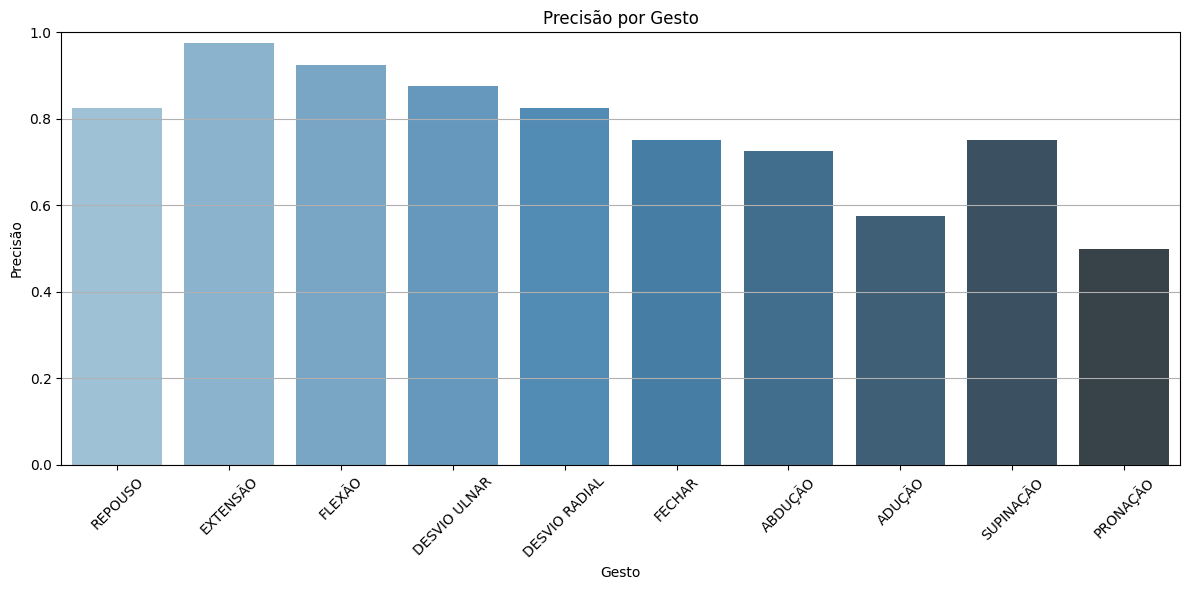

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=labels, y=precision_per_class, palette="Blues_d")
plt.ylim(0, 1)
plt.title("Precisão por Gesto")
plt.ylabel("Precisão")
plt.xlabel("Gesto")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()